### Correlation & Covariance

> Neden önemli? ML modelinde hangi feature'ların işe yarayıp yaramadığını, hangilerinin birbirini tekrarladığını korelasyonla anlarsın. Gereksiz feature → model karmaşıklaşır, overfitting riski artar.

In [ ]:
#Covariance
# iki variablesin birlikte nasil hareket ettigini olcer

# X arrtiginda Y artiyorsa -> positive covariance
# X arttiginda Y azaliyorsa -> negative covariance
# no relationship -> 0 yakin


# Problem is -> Birimi var, yorumlamasi zor
# Covariance = 2500 -> buyuk mu kucuk mu? bilinmez ====> That is why correlation used

# positive covariance and negative covariance
# calisma saati arttikca puan artiyor => positive
# oyun saati arttikca puan dusuyor => negative
# ayakkabi numarasi ve maas arasindaki iliski => yok 0


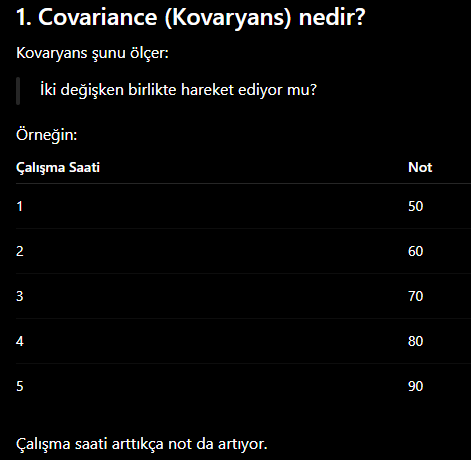
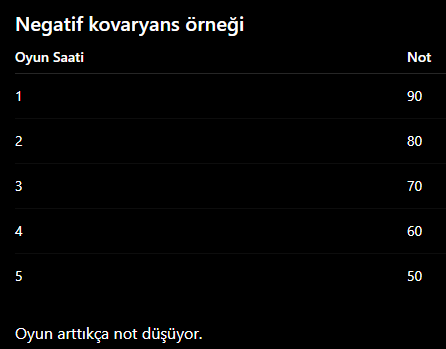

In [ ]:
import pandas as pd
import numpy as np

# Covariance hesaplama
# İki değişken ortalamalarından aynı anda mı uzaklaşıyor?

points = pd.DataFrame({
    "study_h" : [1,2,3,4,5], # mean 3
    "points": [50, 60, 70, 80, 90] # mean 70
})

# ! 1 < 3 yani study hourin ilk elementi 1, study_hin meaninden kucuk
# ! ayni sekilde pointsin ilki elementi 50 < 70 den.
# dolayisiyla X (study_h) ve Y (points) ilk satirlari (1 ve 50) kendilerinin ortamalarindan (3 ve 70) den kucuk
# son satirlari (5 ve 90) de ortalamalarindan buyuk, demek kowaryans pozitif 
# X - X_ = 1-3 = - 2
# Y - Y_ = 50 - 70 = - 20
# (-2) * (-20) = 40
# 5 - 3 = 2
# 90 - 70 = 20 
# 2*20 = 40

# Aynı yönde hareket
# X ortalamanın altında
# Y ortalamanın altında
# veya
# X ortalamanın üstünde
# Y ortalamanın üstünde
# ise çarpım pozitif olur.
points = pd.DataFrame({
    "play_h" : [1,2,3,4,5], # mean 3
    "points": [90, 80, 70, 60, 50] # mean 70
})

# ilk satir X = 1 < 3 = ortalamanin altinda => -2
# son satir Y = 90 > 70 = ortalamanin ustunde => 20

# (−2)×(+20)=−40  ===> bu da negative covariance

#! ikisi de ayni taraftaysa positive 
#! biri ustte biri alttaysa negative
points.cov()

#! COVARIANCE OLCEGI YOK => ILISKI DEGISMEDIGI HALDE SONUC DEGISIYOR. OR:

# [50,60,70,80,90] ==> [5000,6000,7000,8000,9000] - ILISKI DEGISMEDIGI HALDE SONUC DEGISIYOR
# BU YUZDEN COVARIANCE YONU GOSTERIR, GUCU DEGIL


# ex. Cpu guclu oldukca response time de artiyor, 
# Cpu yuku arttikca ram bosaliyor


,play_h,points
play_h,2.5,-25.0
points,-25.0,250.0


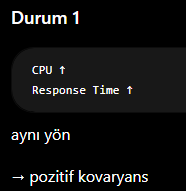
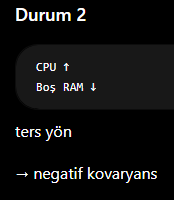

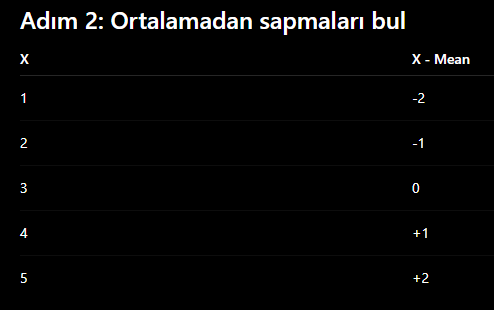
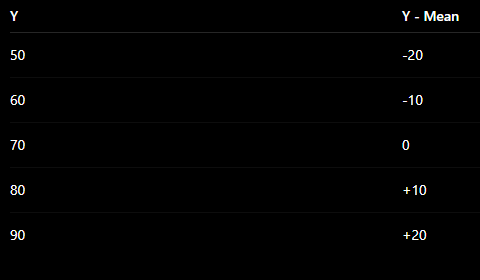
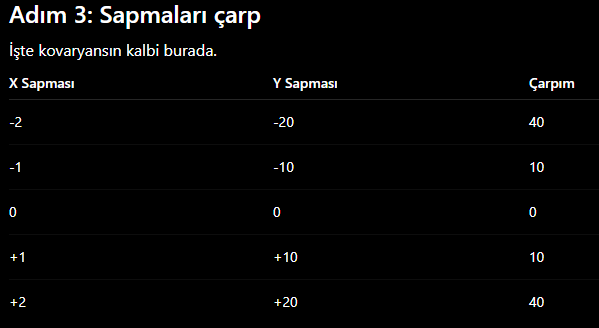
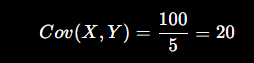
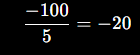

In [6]:
points['study_h'].mean()
points['points'].mean()
# 40 + 10 + 0 + 10 + 40 = 100

np.float64(70.0)

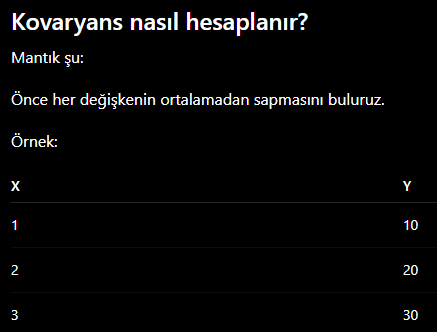

> iliski degismedigi halde sonuc degisir

> covariance yonu gosterir, gucu gostermekte kotu bir olcudur.

> o yuzden df.cov() yerine df.corr() kullanilir

In [ ]:
# Correlation - Pearson => dogrusal iliski

# !Ölçekten bağımsız hale getirilmiş kovaryanstır.

# ! Covariance standardize eder -1 ile 1 arasina sikistirir

# +1.0  →  mükemmel pozitif ilişki
# +0.7  →  güçlü pozitif ilişki
# +0.3  →  zayıf pozitif ilişki
#  0.0  →  ilişki yok
# -0.3  →  zayıf negatif ilişki
# -0.7  →  güçlü negatif ilişki
# -1.0  →  mükemmel negatif ilişki


#** EXamples:
# Ev buyuklugu & fiyat => +0.85 guclu pozitif
# sigara & omur => -0.70 guclu negatif
# ayakkabi numarasi & maas ==> 0.02 iliski yok, no relation

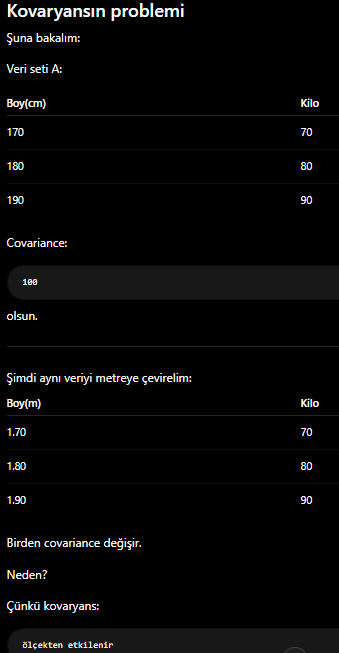

> Correlation nedensellik midir?

> NO way


Pearson
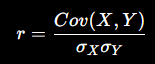

In [13]:
#Burada covariancy standard sapmalara boluyoruz
#covariance olcekten etkileniyor, yani 1.70 cm 80 kg boy ile 170 m 80 kg  

#! dolayisiyla correlation olcekten bagimsiz hale getirilen covariancetir. o yuzden tek basina yorumlamak zordur.
points.corr()
#! −1 ≤ r ≤ 1
# ! Note = Correlation != Causation, yani dondurma yemek gune yanmaga sebap daldir, burada hidden variable is sicak hava
# correlation is not causation

,play_h,points
play_h,1.0,-1.0
points,-1.0,1.0


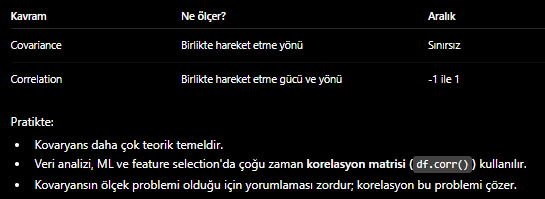

In [ ]:
# Dondurma satisi & gune yanmak / suwda yuzup bilmezlik => 0.95 correleation bar
# Ama ikisi birlikte artmasina ragmen, yani dondurma yemek gune yanmagy doretmeyar yada suwda yuzup bilmezligi anlatmiyor
# !her ikisi de sicak havayla iliskili artiyor. Hidden variable is SEASON

In [ ]:
# Correlation - Spearman ==> monoton iliski, siralama bazli

# Veri normal dagilmiyorsa
# outliers varsa 
# correlation linear degil, ama monotonsa (ikis birlikte artiyor ama orantili degil)



In [ ]:
# Covariance

import numpy as np
import pandas as pd

df = pd.DataFrame({
    'metrekare': [50, 80, 120, 200],
    'fiyat':     [100, 150, 220, 400],
    'bina_yasi': [30, 20, 5, 2]
})

# Tek sütun çifti arasında
cov_value = df['metrekare'].cov(df['fiyat']) # population ddof = 1 as default. metrekarenin fiyata iliskisi
print(cov_value)  # 8508.33 ← pandas n-1 böler (sample), biz n böldük (population)

# Tüm tablo — kovaryans matrisi
cov_matrix = df.cov(ddof=0) # ddof=0 sample
print(cov_matrix)

# metrekare & fiyat    →  +8508  →  pozitif, aynı yönde
# bina_yasi & fiyat    →  -808   →  negatif, ters yönde (yaşlı bina → düşük fiyat)
# metrekare & bina_yasi → -408   →  negatif (büyük evler daha yeni)

#! Problem: 8508 mi büyük, 808 mi küçük? Karşılaştıramazsın — birimler farklı.

-1499.1666666666665
           metrekare      fiyat  bina_yasi
metrekare   3168.750   6381.250  -578.1250
fiyat       6381.250  12918.750 -1124.3750
bina_yasi   -578.125  -1124.375   129.1875


In [ ]:
# Kovaryans → Korelasyon: Standardizasyon
# Korelasyon = kovaryansı standardize et
# corr(X,Y) = cov(X,Y) / (std(X) * std(Y))

# Correlation from covariance
std_m = df['metrekare'].std(ddof=0)  # with ddof = 1 = > 167.08
std_f = df['fiyat'].std(ddof=0)      #  with ddof = 1 => 130.48
print(std_m)
print(std_f)
corr_elle = cov_value / (std_m * std_f)
print(corr_elle)  # 0.972

# Pandas ile direkt:
corr_matrix = df.corr()
print(corr_matrix)

56.29165124598851
113.66067921669305
-0.2343126209656867
           metrekare     fiyat  bina_yasi
metrekare   1.000000  0.997359  -0.903582
fiyat       0.997359  1.000000  -0.870343
bina_yasi  -0.903582 -0.870343   1.000000


=== KOVARYANS ===
               fiyat  metrekare  oda_sayisi  bina_yasi      kat
fiyat       26342.86    9800.00      269.29   -1971.43  1067.14
metrekare    9800.00    3678.57       99.64    -728.57   397.86
oda_sayisi    269.29      99.64        2.84     -21.29    10.82
bina_yasi   -1971.43    -728.57      -21.29     176.57   -75.29
kat          1067.14     397.86       10.82     -75.29    44.79

=== KORELASYON ===
            fiyat  metrekare  oda_sayisi  bina_yasi   kat
fiyat        1.00       1.00        0.98      -0.91  0.98
metrekare    1.00       1.00        0.97      -0.90  0.98
oda_sayisi   0.98       0.97        1.00      -0.95  0.96
bina_yasi   -0.91      -0.90       -0.95       1.00 -0.85
kat          0.98       0.98        0.96      -0.85  1.00

=== FİYATLA KORELASYON ===
fiyat         1.000000
metrekare     0.995532
oda_sayisi    0.984640
kat           0.982475
bina_yasi    -0.914091
Name: fiyat, dtype: float64


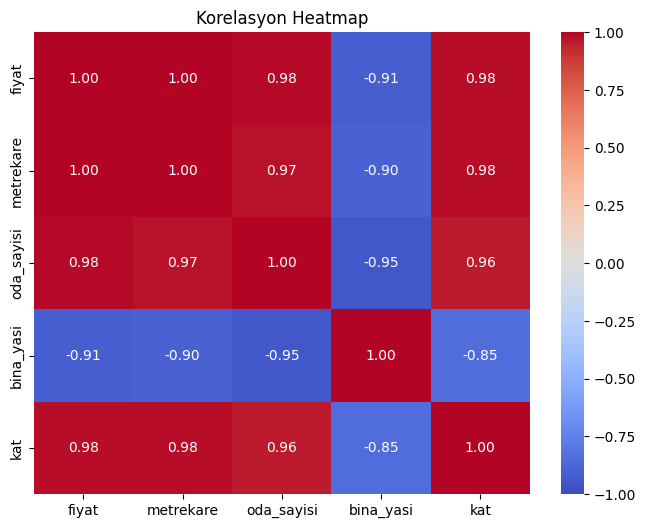

In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Örnek veri seti — ev fiyatları
df = pd.DataFrame({
    'fiyat':      [200, 350, 180, 500, 420, 150, 600, 280],
    'metrekare':  [80,  130, 70,  200, 160, 60,  220, 100],
    'oda_sayisi': [2,   4,   2,   5,   4,   1,   6,   3  ],
    'bina_yasi':  [25,  10,  30,  5,   8,   40,  3,   15 ],
    'kat':        [3,   7,   2,   15,  9,   1,   20,  5  ]
})

# Adım 1 — Kovaryans matrisi
print("=== KOVARYANS ===")
print(df.cov().round(2))

# Adım 2 — Korelasyon matrisi
print("\n=== KORELASYON ===")
print(df.corr().round(2))

# Adım 3 — Hedefle korelasyon, sıralı
print("\n=== FİYATLA KORELASYON ===")
print(df.corr()['fiyat'].sort_values(ascending=False))

# Adım 4 — Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), 
            annot=True,      # değerleri göster
            cmap='coolwarm', # kırmızı=pozitif, mavi=negatif
            fmt='.2f',       # 2 ondalık
            vmin=-1, vmax=1) # ekseni sabitle
plt.title('Korelasyon Heatmap')
plt.show()

In [ ]:
# Tehlikeli yüksek korelasyon — feature'lar arası
corr = df.corr()

# 0.90 üzeri korelasyonları bul
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i,j]) > 0.90:
            high_corr.append({
                'feature_1': corr.columns[i],
                'feature_2': corr.columns[j],
                'korelasyon': corr.iloc[i,j].round(3)
            })

print(pd.DataFrame(high_corr))

# feature_1   feature_2   korelasyon
# metrekare   oda_sayisi  0.982      ← tehlikeli! | multicollinearity var
# metrekare   fiyat       0.998      ← bu hedefle, sorun değil

# metrekare ve oda_sayisi arasında 0.982 → ikisini birden Linear Regression'a verme. Biri yeterli.

    feature_1   feature_2  korelasyon
0       fiyat   metrekare       0.996
1       fiyat  oda_sayisi       0.985
2       fiyat   bina_yasi      -0.914
3       fiyat         kat       0.982
4   metrekare  oda_sayisi       0.975
5   metrekare   bina_yasi      -0.904
6   metrekare         kat       0.980
7  oda_sayisi   bina_yasi      -0.951
8  oda_sayisi         kat       0.960


In [ ]:
# *df.cov()              →  yön anlamak için (+ mı - mı)
# *df.corr()             →  güç ölçmek için (-1 ile +1)
# *df.corr(method='spearman') →  normal dağılmayan veri için
# *sns.heatmap(df.corr()) →  görsel analiz, EDA'da her zaman